# Assignment 2: Network Generation and Validation 
## Task 
This worksheet will look into the undertaking of generating a Randomised Erdős–Rényi network of sizes ranging from 20-50k and attempt to rewire as many nodes as possible to form into cliques that are close to a specified target (in this case 5). All the while minimuising the impact of the overall degree distribution. 

## Task Observations and Assumptions
Given the task, there have been a few core things to note during the running of this tasks: 
1. Degree Distribution is unlikely to stay the same during the rewiring process. As such, there is an allowance for a +/- variance of 10% from the original value before stopping the rewiring process. 
2. There is no minimum quota on how many cliques should be rewired to meet the target or be in close proximity to it. The objective is to try do as many as possible. This could mean the number of cliques formed can vary in size and at times may be small.  
3. To improve the efficiency of the rewiring process, we ignore cliques that are already close to the target value. The same is done during rewiring using a rewiring cache. 
4. This code is adjustable and as such there have been some measures put in place to stop certain failing scenarios occuring (like asking for more cliques than you have nodes)
5. The code is broken up to be more modular and to enforce clean coding practices (DRY, Low Coupling, High Cohesion, and no more than 30 lines of code per method or function).  
6. It was noted that some issues were occuring when runing multiple simlations in the one go. As such, garbage collection is carried out after every simulation to clear down as much unused memory use as possible. 
7. There are only two other files outside of this notebook to be aware of, these are the NetworkGenerator.py and the Rewirer.py. If these are not present in the provided folder then this notebook will not run.
8. The networks generated are random, as is degree distribution. It is unlikely that you will encounter two networks with the same values in a previous run, if you do, you may wish to repeat the notebook. 
9. To prevent the rewiring process taking an excessively long time, two conditions were created. The first is Max Consequtive Failures, which stops the rewiring process if something within the rewiring process does not comply with the allowed rewiring rules (no missing edges, average degree now crosses allowed threashold, rewiring process attempted to use a node already rewired)Max Attempts, which prevents the network from trying too many different combinations of rewiring.


## Step 1 Import required packages
If these are not installed on your machine the below command should be able to install them for you. 


In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\RRHMc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
import random as rng
import gc
from NetworkGenerator import NetworkGenerator
from Rewirer import Rewirer
from ReportingModule import ReportingModule

## Step 2: Network reporting implementation

### Step 2.1: Network Reporting Class 
Initialising this class enables the core part of the reporting process to be carried out

In [3]:
reporter = ReportingModule()

In [4]:
def _log_network_state(label: str, ntwk) -> None:
    """
    Print a labelled snapshot of the network through ReportingModule.

    @param label: Descriptive heading for this snapshot.
    @param ntwk: The network to log.
    """
    reporter.log_network_state(label, ntwk)

### Step 2.2: Implement Network validation code
The code below will do our final check that the ER network that has been rewired is within our allowed percentage range for changes to Degree Distribution 

In [5]:
def validate_er_network(ntwk, original_degree_sequence):
    """
    Validate that the rewired network's mean degree is within +/- 10% of the
    original ER graph's mean degree.

    @param ntwk: The rewired network to validate.
    @type  ntwk: nx.Graph
    @param original_degree_sequence: Degree sequence of the pre-rewiring graph.
    @type  original_degree_sequence: list[int]
    @return: True if the degree distribution is within tolerance.
    @rtype:  bool
    """
    original_avg_degree = np.mean(original_degree_sequence)
    current_avg_degree = reporter.get_avg_degree_dist(ntwk)

    if original_avg_degree == 0:
        return current_avg_degree == 0

    return (
        abs(current_avg_degree - original_avg_degree) / original_avg_degree <= 0.10
    )

## Step 3 Run a single Trial Simulation
**Note:** The code below contains the core Network Generation, Rewiring, and Reporting process. 
The output can be broken down into two core parts - the state before rewiring, and the state afterwards. The former, includes details of the current degree distribution in both visual and textual form, and the count of cliques within the network. The latter also has these in the updated state and extends this to include metrics about the rewiring process, but also the metrics required to complete the rewiring process. 

Before moving to do multiple simuilations of this process, lets first check the output of a single runthrough. 

ER network created
Average degree: 17.0412


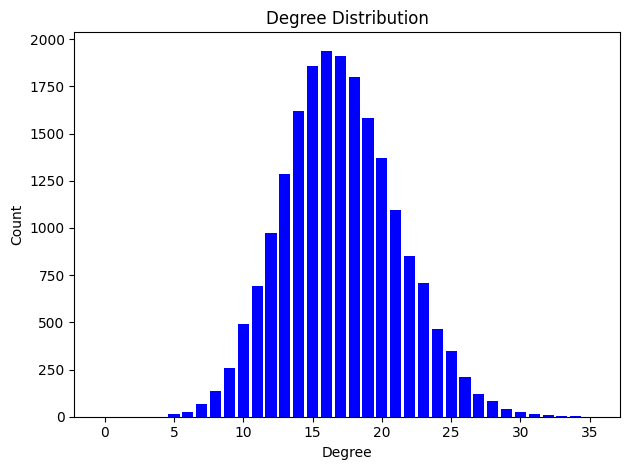

Clique size distribution (raw counts):
  Size 2: 167965 clique(s)
  Size 3: 821 clique(s)
Clique sizes present: 2, 3


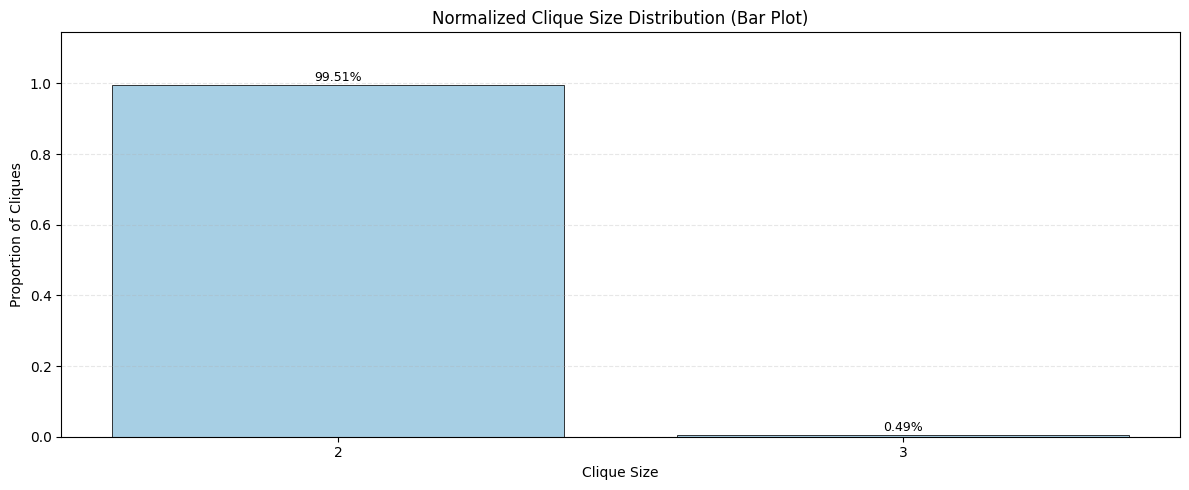

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 201903
  successful rewires  : 1707
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 200196
  avg degree          : 17.0412 -> 18.7453
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Average degree: 18.7453


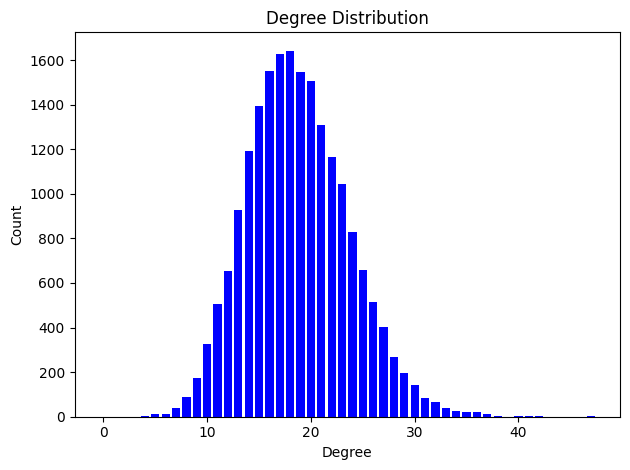

Clique size distribution (raw counts):
  Size 2: 167483 clique(s)
  Size 3: 1070 clique(s)
  Size 5: 1705 clique(s)
Clique sizes present: 2, 3, 5


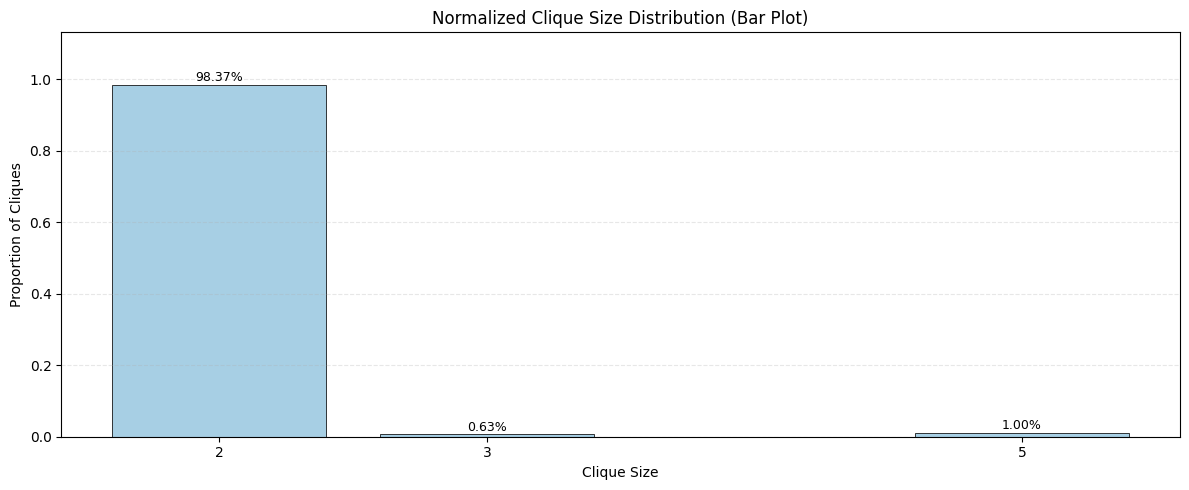

(np.True_, <networkx.classes.graph.Graph at 0x1c4ee2ac3d0>)

In [6]:
def run_single_network_simulation(num_nodes, kmean, clique_size, visualise=False):
    """
    Generate a connected ER graph, rewire it with cliques, and validate.

    @param num_nodes: Number of nodes in the generated graph.
    @param kmean: Target mean degree for the ER graph.
    @param clique_size: Target clique size passed to the rewirer.
    @param visualise: Print stats and plot distributions when True.
    @return: Tuple of (is_valid, rewired_network).
    """
    ntwk = NetworkGenerator(num_nodes, kmean).generate_erdos_renyi_graph(require_connected=True)
    original_degree_sequence = sorted([d for _, d in ntwk.degree()])
    if visualise:
        _log_network_state("ER network created", ntwk)
    rewirer = Rewirer(ntwk)
    ntwk = rewirer.rewire_network_cliques(clique_size, print_stats=visualise)
    model_valid = validate_er_network(ntwk, original_degree_sequence)
    if visualise:
        _log_network_state(f"ER network rewired ({'valid' if model_valid else 'invalid'})", ntwk)
    del original_degree_sequence, rewirer
    gc.collect()
    return model_valid, ntwk


run_single_network_simulation(20000, rng.randint(5, 20), 5, visualise=True)


### How to know that the work done is valid? 
Given the size and nature of the process carried out, it would be quite difficult to visually demonstrate the changed state between the original and rewired network. When looking at the ER network's degree distribution, in histograph form, the behiour of the total for degree distribution counts should follow the form of a bell curve. Should the rewired network not have a similar behaviour then we can deem the rewiring process unsuccessful. Another way to check that the rewiring process has been successful is the average degree distribution. The average value of the degree distribution should be retained within 10% of the original value. To save time on the calculation, a validation check will indicate whether the network is valid or not for this and can be seen in the above log after the simulation has been run. Lastly, the bar graph indicating clique count percentages should demonstrate a change in clique totals to see an increase in the direction of the target value. At times, results may see a slim change compared to the original network. So as long as there is evidence that rewiring has achieved some clique formations close to the target value without excessively chaning the degree distributions, then the process is deemed successful 

### Output from simulation 
With the original rewired diagram, typically returning cliques of majority size 2 and a small number of size 3. We would look to increase as many of those cliques at size two to be moved to within the numbers surrounding 5 as possible. Rewiring may take some time depending on the complexity of the network, but previous runs indicated that between 1-2 mins on a machine with adequate resources to process is the average. 
After Rewiring, we typically see a specific increase in the number of cliques which are of the target value and a slight increase in the surrounding values as well. As an interesting observation, the rewiring process is able to form cliques of size 5 and 3, but has difficulty at times form cliques of size 4. Another observation is that the network still retains a majority of cliques of size 2. It is likely that this is because impacting this siginficantly would change the average degree distribution beyond acceptable limits, and so we will likely not see a drastic change in the number of cliques of size 2. From looking as well at the output from the rewiring process, the reason for rewiring terminating is due to the limit on the number of failures being reached, suggesting that the process could not proceed any further without breaking one of the assumptions or critiera that was mentioned in the Assumptions and Notes section. 
### Conclusion
With this in mind, this single experiment should have demonstrated compliance with the requirements of the task and returned a valid rewired network with clique totals closer to the target value. 

## Step 4: Run Multiple Simulations

Now that it is possible to show that a random ER network can be rewired, lets try a number of different random networks with a slightly larger node range than what was used in the initial run. 

### Step 4.1 Run Multiple simulations within a 20-30k Node range

Running simulation 1/5
ER network created
Average degree: 16.04965415019763


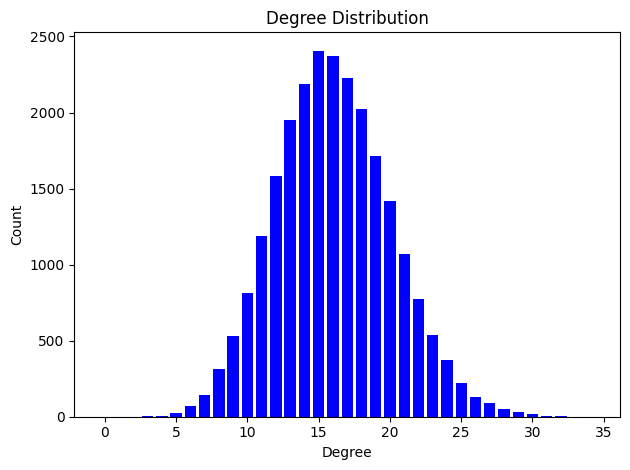

Clique size distribution (raw counts):
  Size 2: 192953 clique(s)
  Size 3: 656 clique(s)
Clique sizes present: 2, 3


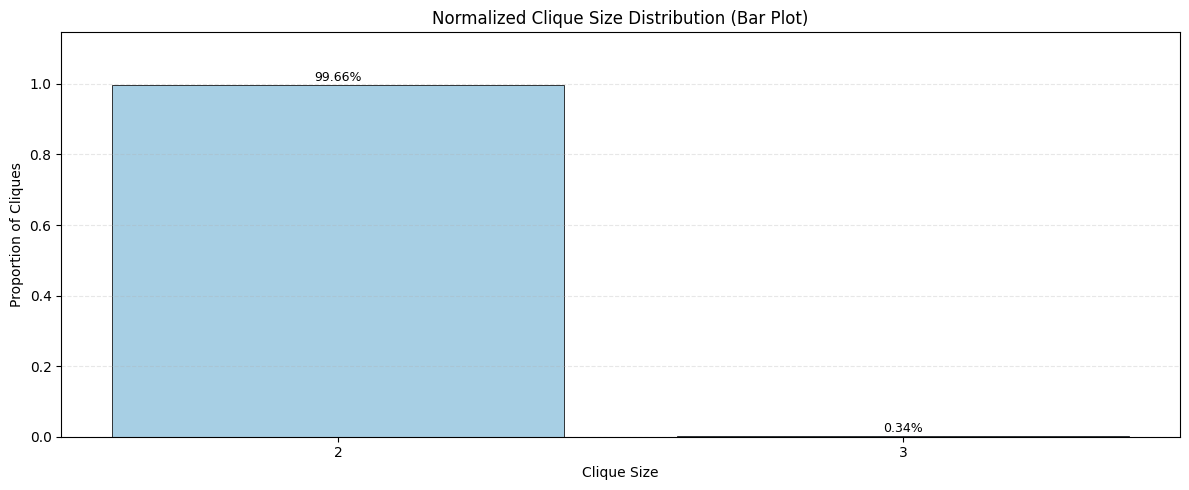

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 248595
  successful rewires  : 1951
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 246644
  avg degree          : 16.0497 -> 17.6546
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Average degree: 17.654561923583664


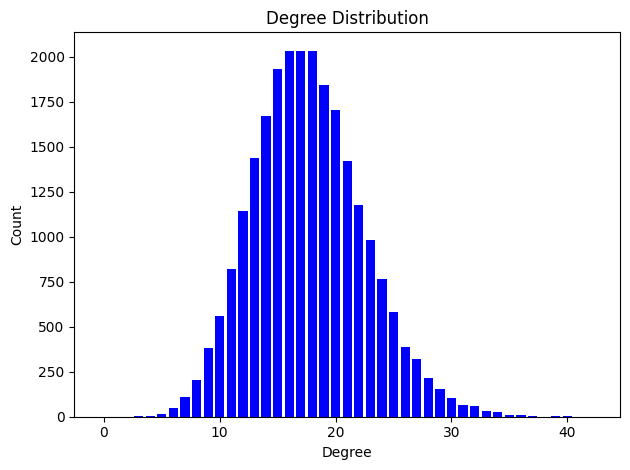

Clique size distribution (raw counts):
  Size 2: 192471 clique(s)
  Size 3: 907 clique(s)
  Size 4: 1 clique(s)
  Size 5: 1949 clique(s)
Clique sizes present: 2, 3, 4, 5


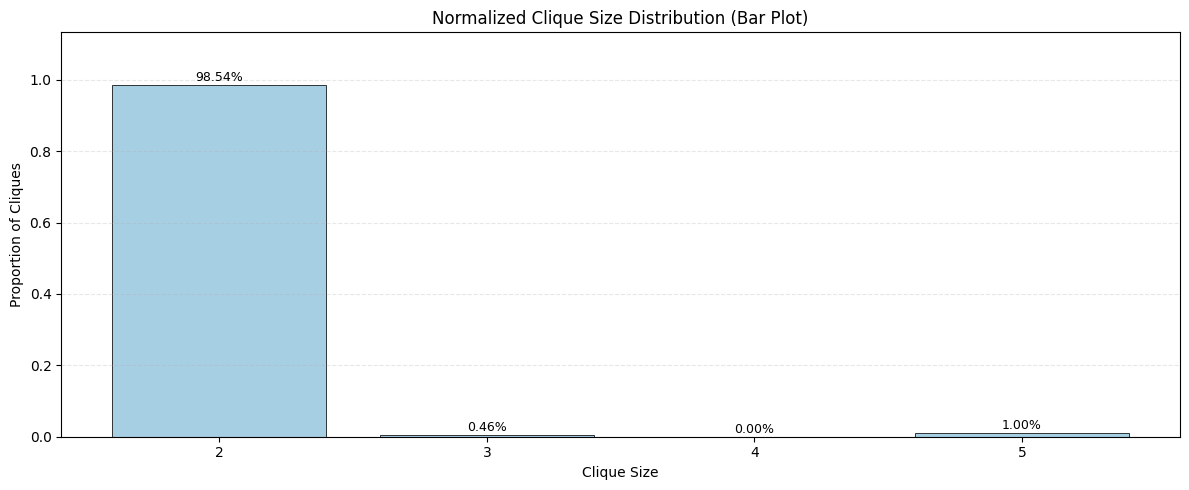

Simulation 1 complete - memory cleared.

Running simulation 2/5
ER network created
Average degree: 31.017476363934023


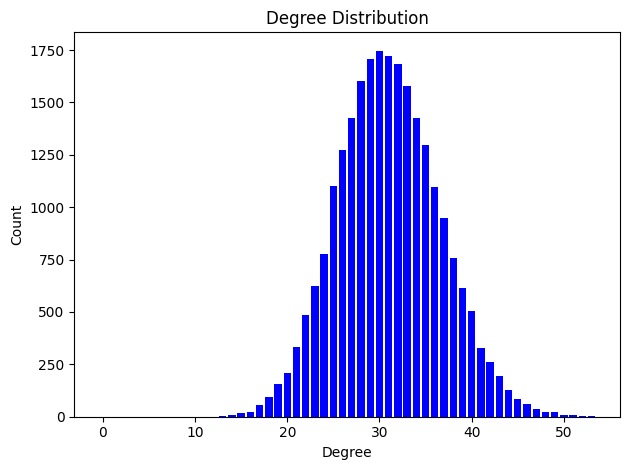

Clique size distribution (raw counts):
  Size 2: 364286 clique(s)
  Size 3: 4988 clique(s)
Clique sizes present: 2, 3


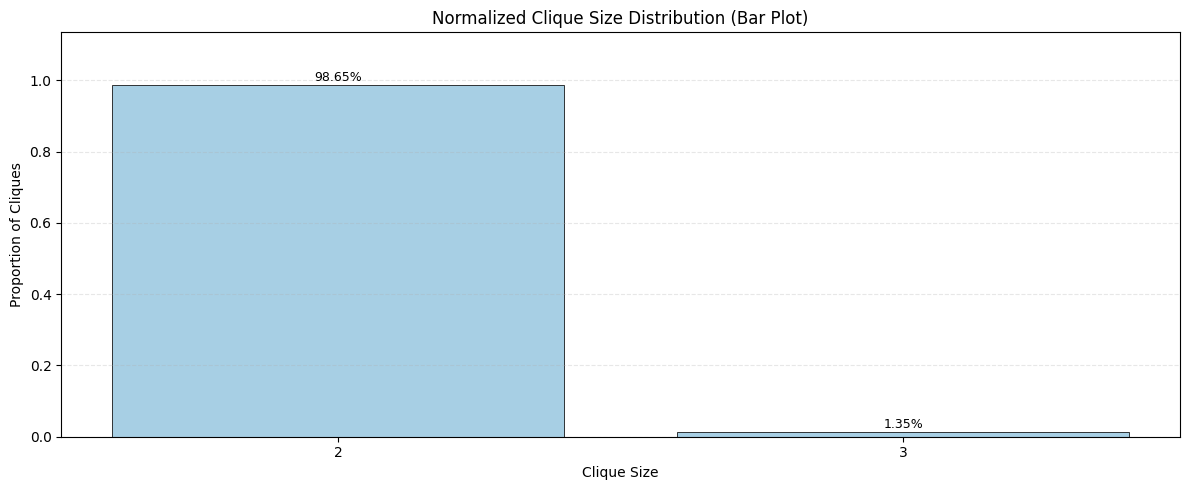

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 248125
  successful rewires  : 3794
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 244331
  avg degree          : 31.0175 -> 34.1191
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Average degree: 34.11910121556911


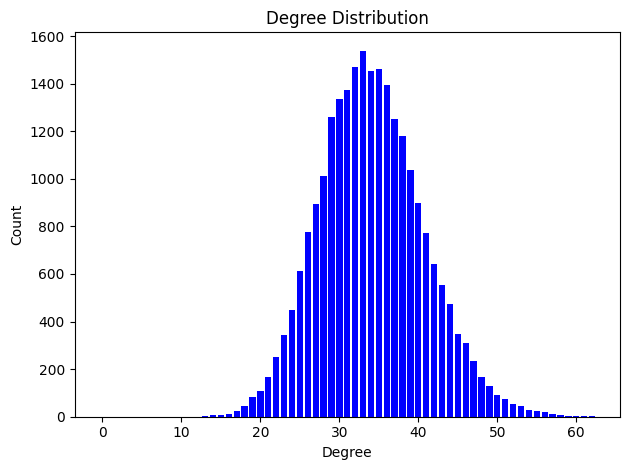

Clique size distribution (raw counts):
  Size 2: 361335 clique(s)
  Size 3: 6587 clique(s)
  Size 4: 1 clique(s)
  Size 5: 3793 clique(s)
Clique sizes present: 2, 3, 4, 5


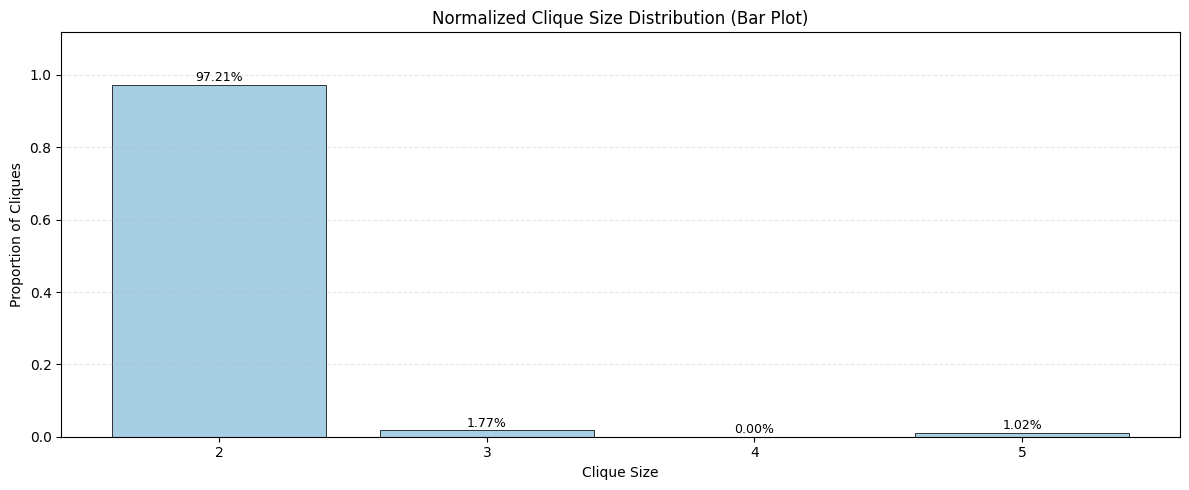

Simulation 2 complete - memory cleared.

Running simulation 3/5
ER network created
Average degree: 34.04728434504792


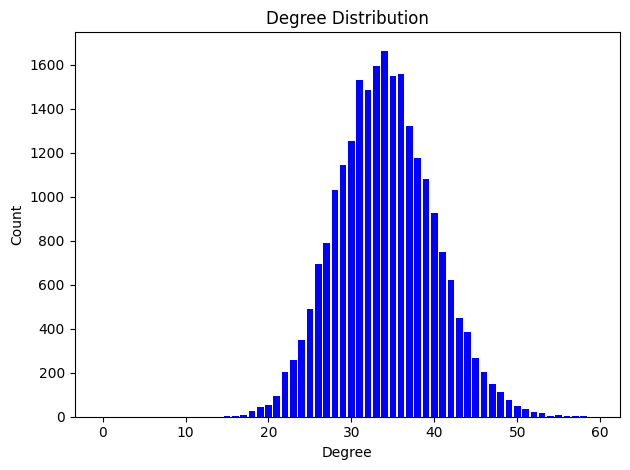

Clique size distribution (raw counts):
  Size 2: 380205 clique(s)
  Size 3: 6639 clique(s)
Clique sizes present: 2, 3


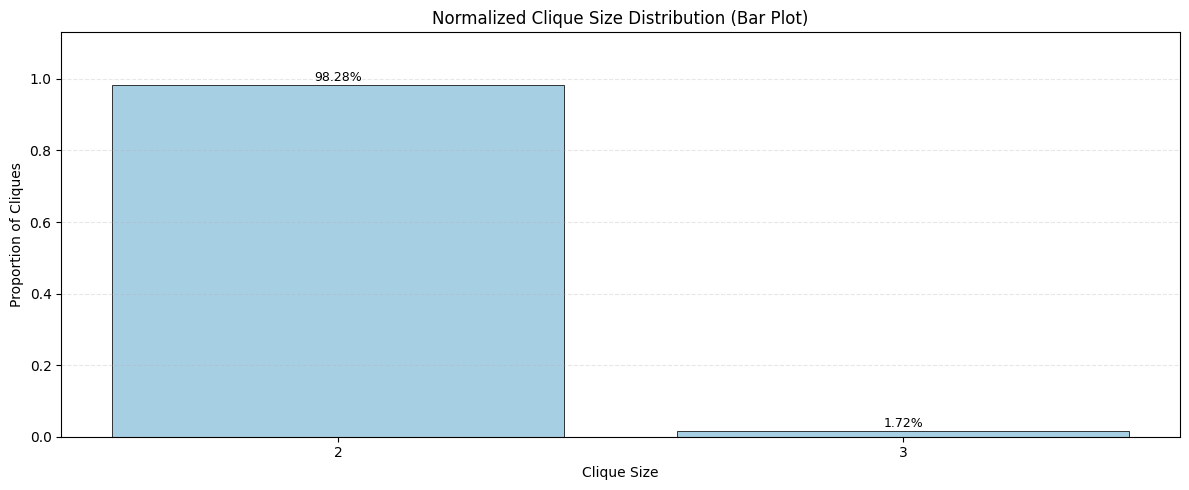

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 238758
  successful rewires  : 4004
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 234754
  avg degree          : 34.0473 -> 37.4519
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Average degree: 37.45192758253461


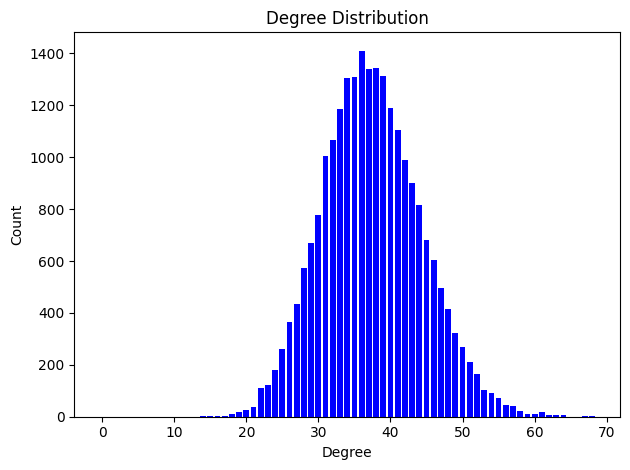

Clique size distribution (raw counts):
  Size 2: 376310 clique(s)
  Size 3: 8760 clique(s)
  Size 4: 5 clique(s)
  Size 5: 4002 clique(s)
Clique sizes present: 2, 3, 4, 5


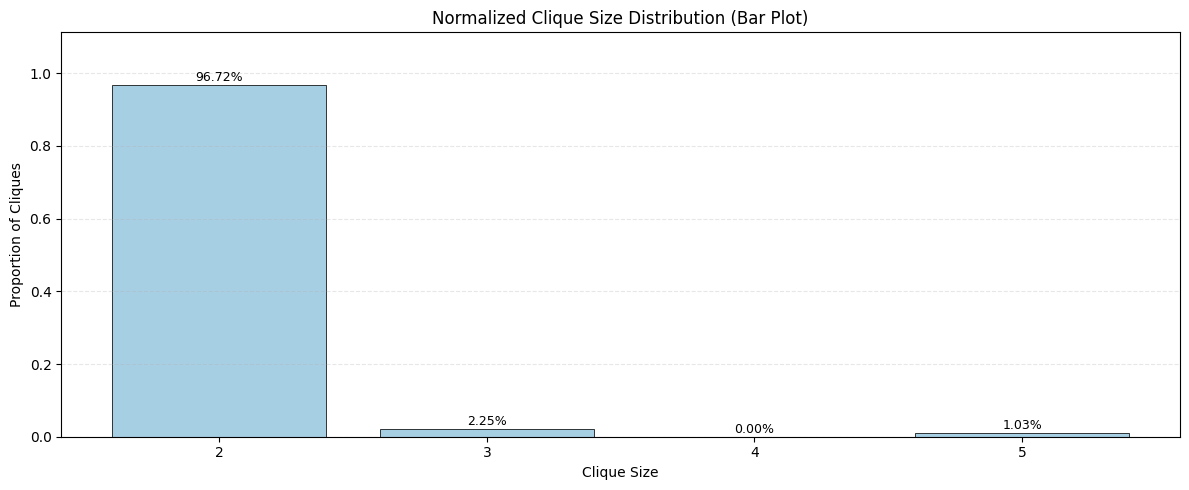

Simulation 3 complete - memory cleared.

Running simulation 4/5
ER network created
Average degree: 45.05127671095931


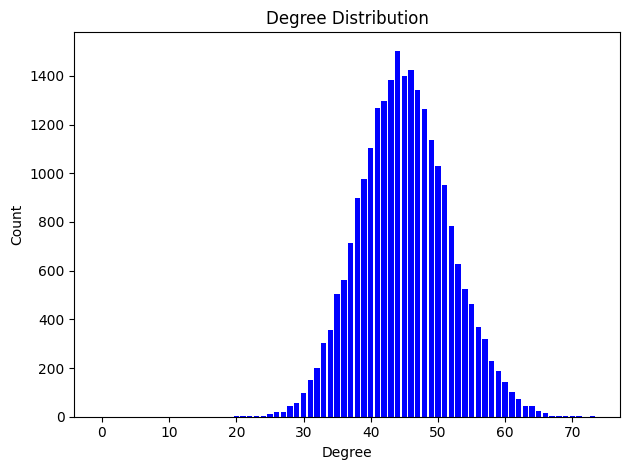

Clique size distribution (raw counts):
  Size 2: 496506 clique(s)
  Size 3: 15365 clique(s)
  Size 4: 3 clique(s)
Clique sizes present: 2, 3, 4


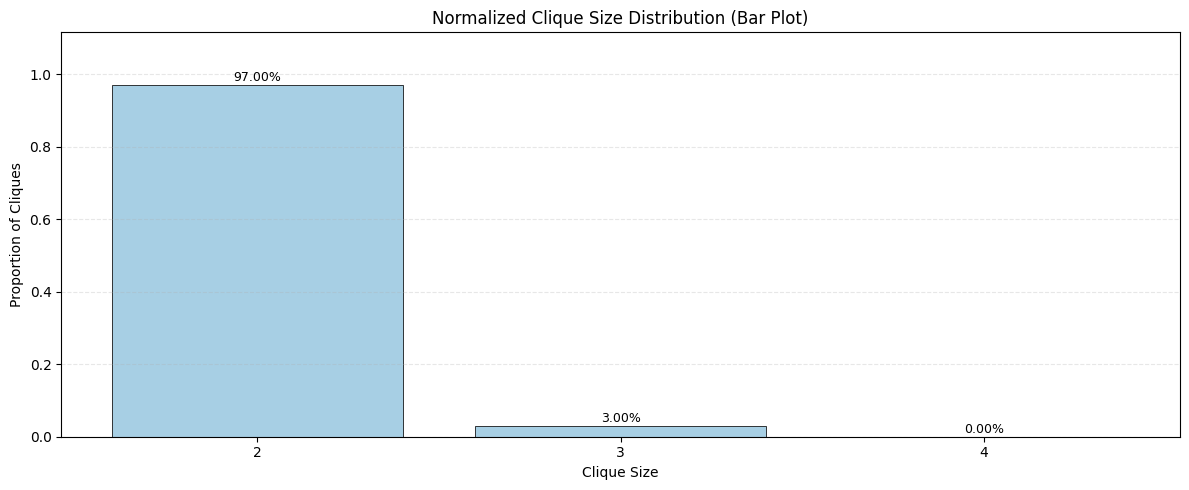

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 340177
  successful rewires  : 5418
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 334759
  avg degree          : 45.0513 -> 49.5564
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Average degree: 49.55637938934478


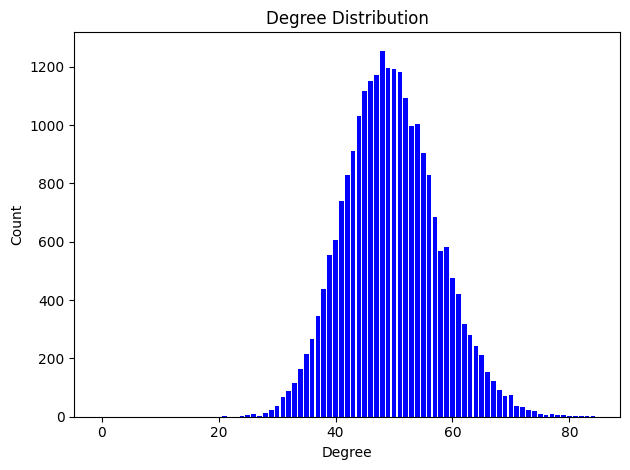

Clique size distribution (raw counts):
  Size 2: 487784 clique(s)
  Size 3: 20352 clique(s)
  Size 4: 17 clique(s)
  Size 5: 5416 clique(s)
Clique sizes present: 2, 3, 4, 5


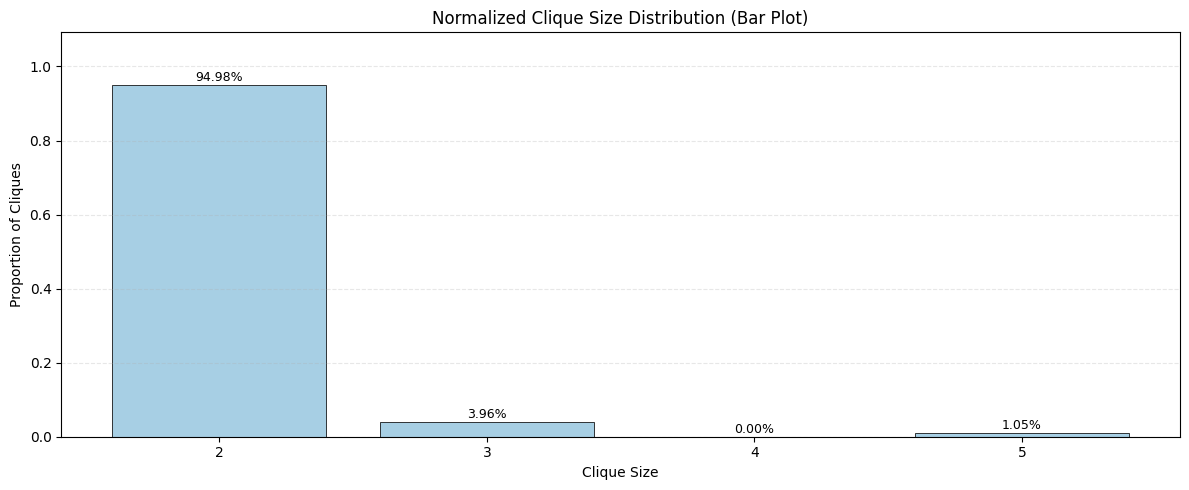

Simulation 4 complete - memory cleared.

Running simulation 5/5
Simulation failed with current values, retrying
ER network created
Average degree: 20.985641651413463


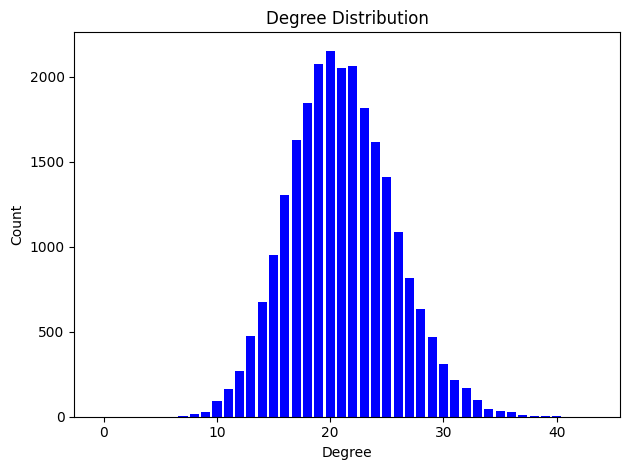

Clique size distribution (raw counts):
  Size 2: 253479 clique(s)
  Size 3: 1507 clique(s)
Clique sizes present: 2, 3


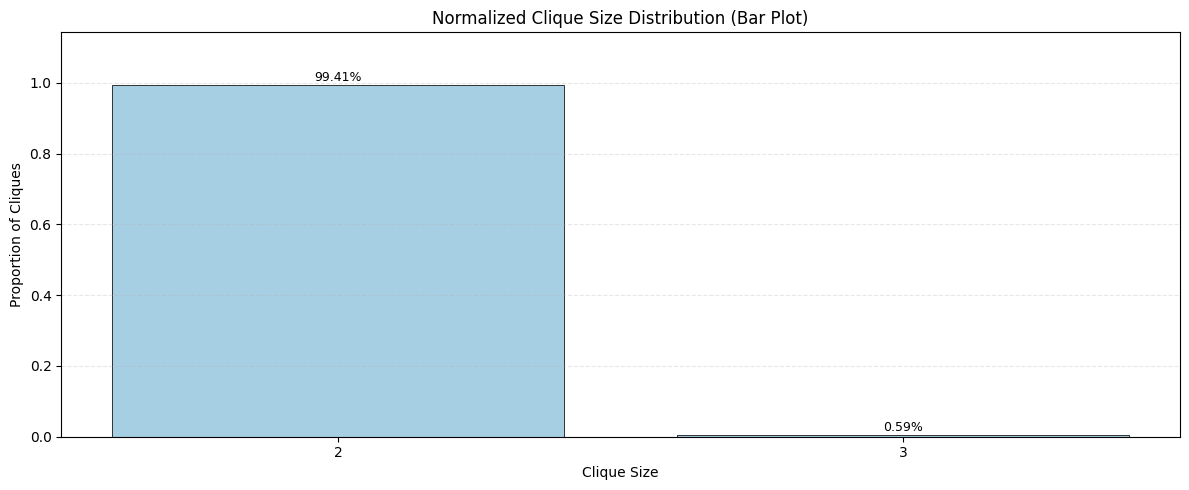

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 248431
  successful rewires  : 2581
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 245850
  avg degree          : 20.9856 -> 23.0841
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Average degree: 23.084075655887737


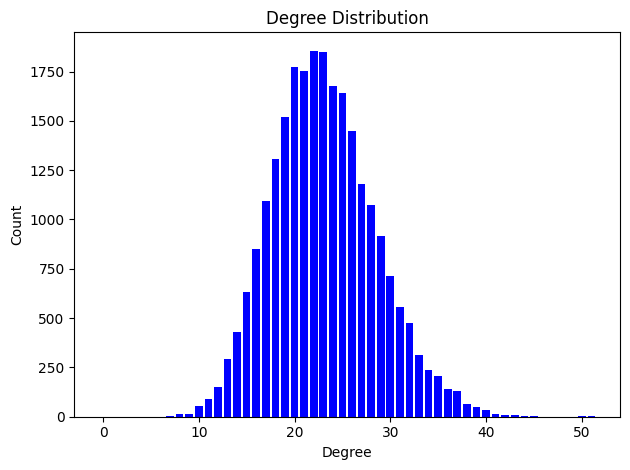

Clique size distribution (raw counts):
  Size 2: 252531 clique(s)
  Size 3: 2007 clique(s)
  Size 4: 1 clique(s)
  Size 5: 2581 clique(s)
Clique sizes present: 2, 3, 4, 5


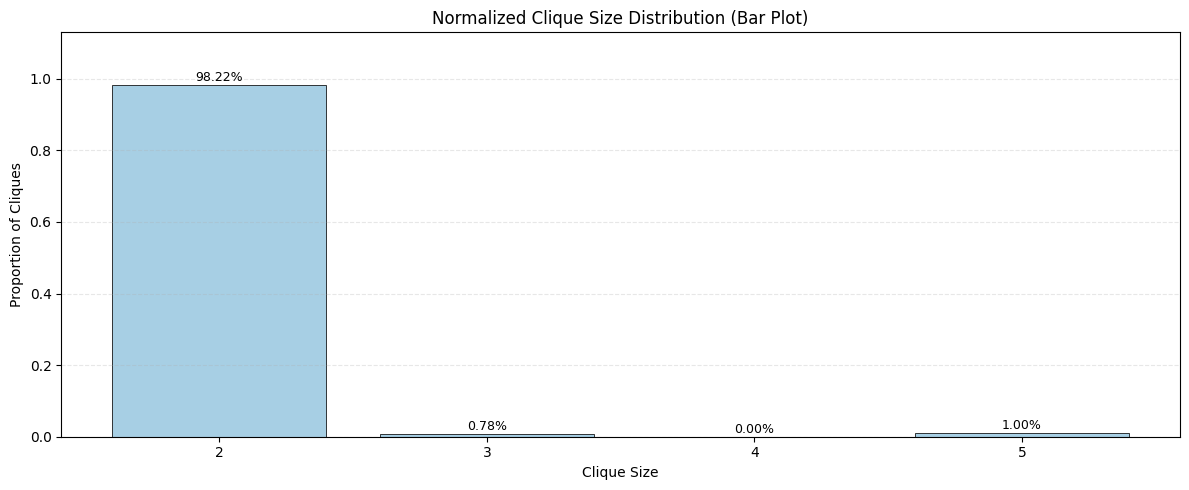

Simulation 5 complete - memory cleared.



In [7]:
def run_multiple_simulations(num_simulations, max_nodes, clique_size, visualise=False):
    """
    Run several independent simulations, clearing memory between each run.

    @param num_simulations: Number of simulations to execute.
    @type  num_simulations: int
    @param max_nodes: Upper bound for the randomly chosen node count.
    @type  max_nodes: int
    @param clique_size: Target clique size passed to each simulation.
    @type  clique_size: int
    @param visualise: If True, print stats and plot distributions per run.
    @type  visualise: bool
    """
    for i in range(num_simulations):
        print(f"Running simulation {i + 1}/{num_simulations}")

        def run_and_validate():
            kmean = rng.randint(5, 50)
            return run_single_network_simulation(
                rng.randint(20000, max_nodes), kmean, clique_size, visualise
            )

        try:
            run_and_validate()
        except ValueError:
            print("Simulation failed with current values, retrying")
            run_and_validate()

        plt.close("all")
        gc.collect()
        print(f"Simulation {i + 1} complete - memory cleared.\n")


run_multiple_simulations(5, 30000, 5, visualise=True)

### Step 4.2 Run Multiple simulations within a 20-40k Node range
**Note:** This may take some time (depending on the machine used) to complete.

Running simulation 1/5
ER network created
Average degree: 45.055193434935525


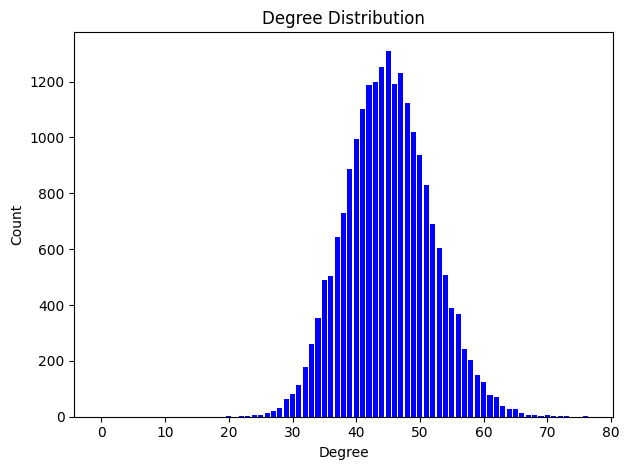

Clique size distribution (raw counts):
  Size 2: 436890 clique(s)
  Size 3: 15218 clique(s)
Clique sizes present: 2, 3


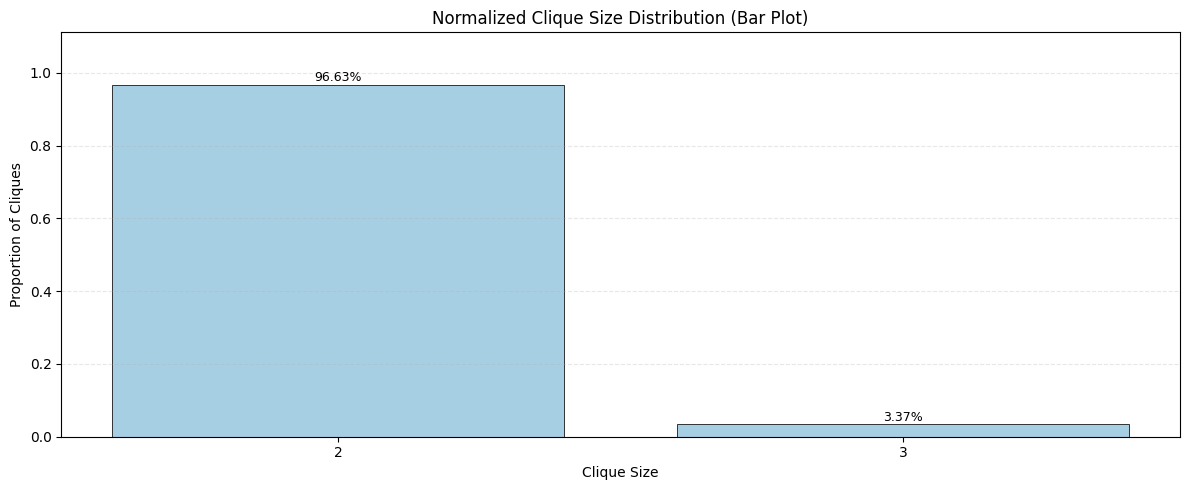

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 218333
  successful rewires  : 4815
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 213518
  avg degree          : 45.0552 -> 49.5607
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Average degree: 49.560703399765536


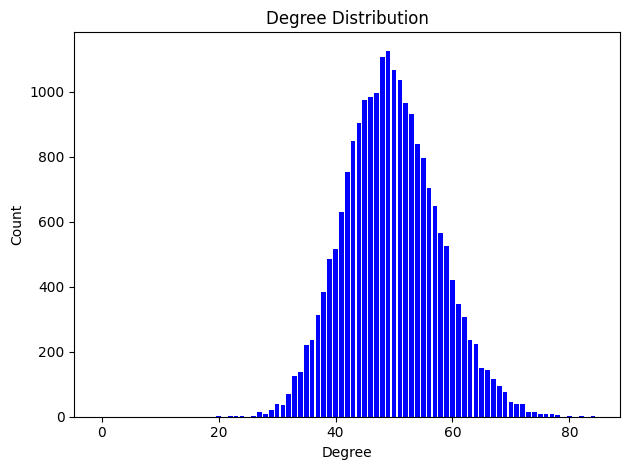

Clique size distribution (raw counts):
  Size 2: 428175 clique(s)
  Size 3: 20234 clique(s)
  Size 4: 15 clique(s)
  Size 5: 4814 clique(s)
Clique sizes present: 2, 3, 4, 5


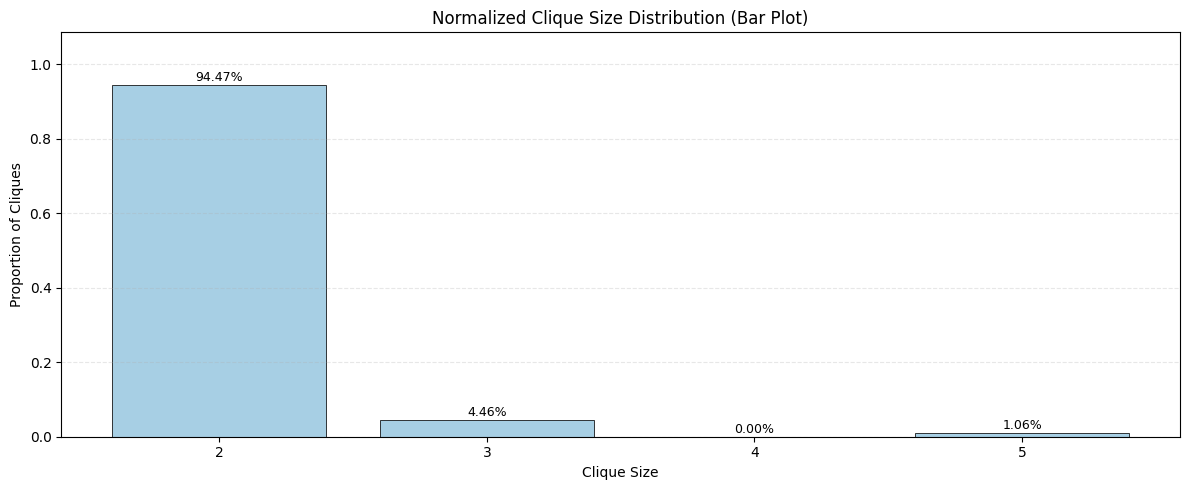

Simulation 1 complete - memory cleared.

Running simulation 2/5
ER network created
Average degree: 15.99227541129721


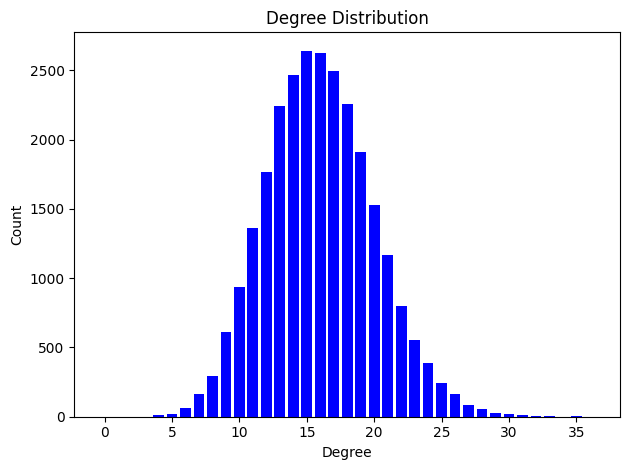

Clique size distribution (raw counts):
  Size 2: 213187 clique(s)
  Size 3: 711 clique(s)
Clique sizes present: 2, 3


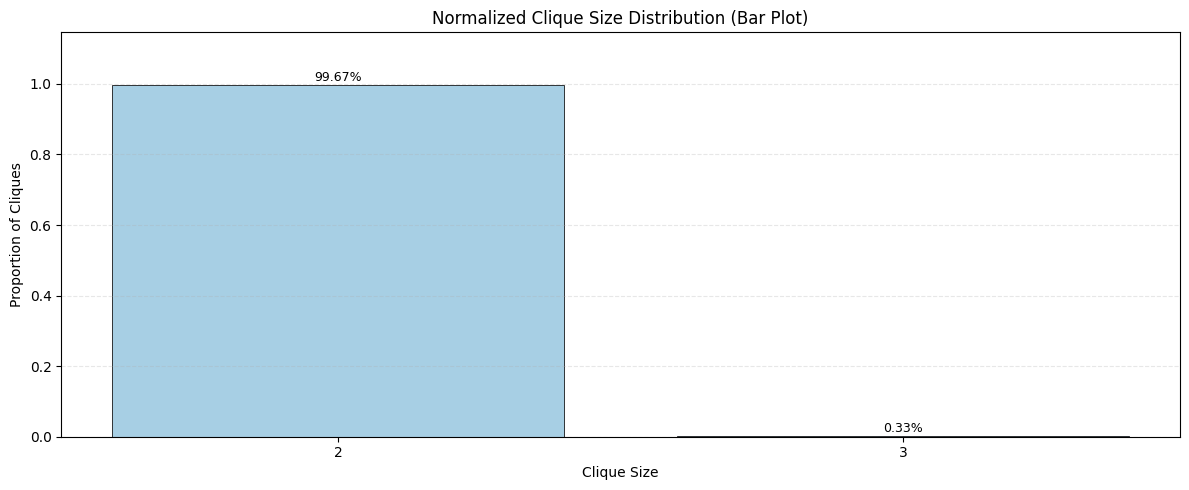

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 271426
  successful rewires  : 2155
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 269271
  avg degree          : 15.9923 -> 17.5914
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Average degree: 17.591413822557286


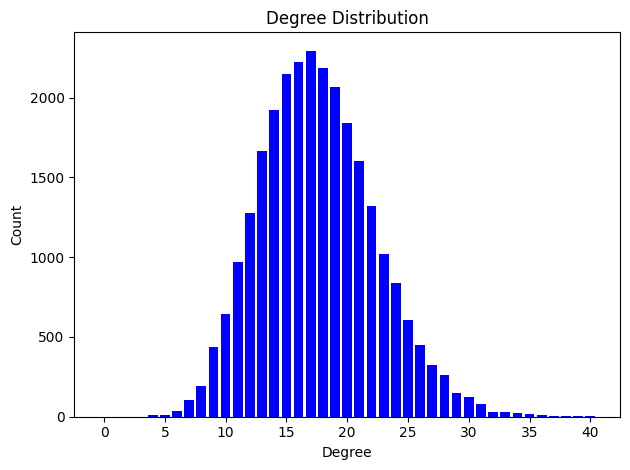

Clique size distribution (raw counts):
  Size 2: 212726 clique(s)
  Size 3: 944 clique(s)
  Size 4: 1 clique(s)
  Size 5: 2154 clique(s)
Clique sizes present: 2, 3, 4, 5


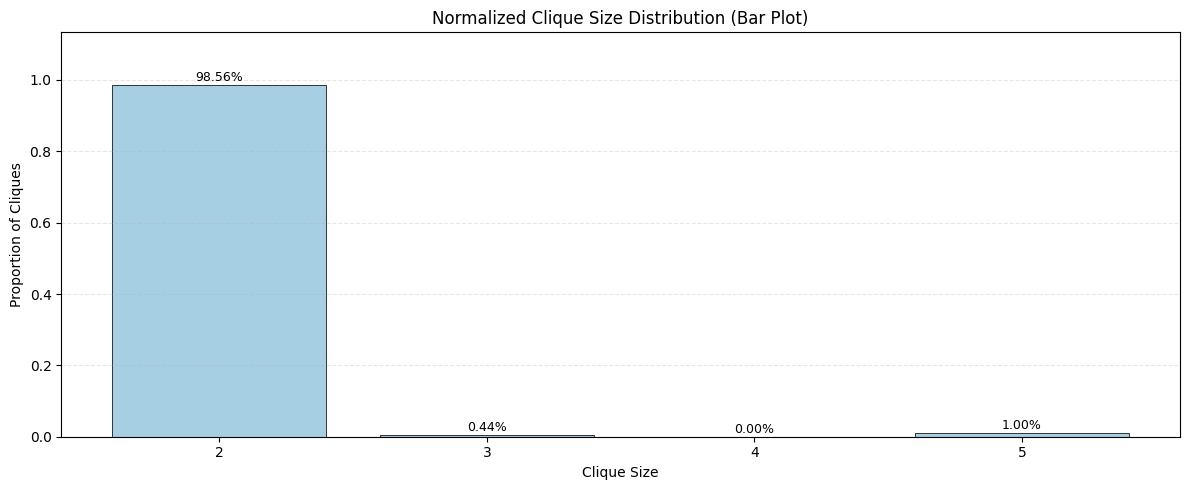

Simulation 2 complete - memory cleared.

Running simulation 3/5
ER network created
Average degree: 34.00414788596079


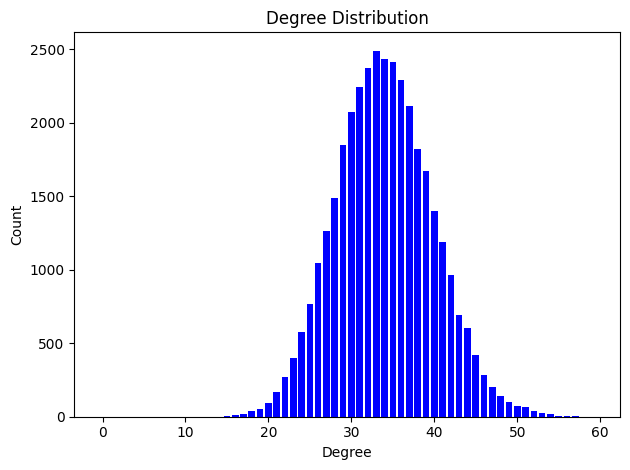

Clique size distribution (raw counts):
  Size 2: 595336 clique(s)
  Size 3: 6618 clique(s)
Clique sizes present: 2, 3


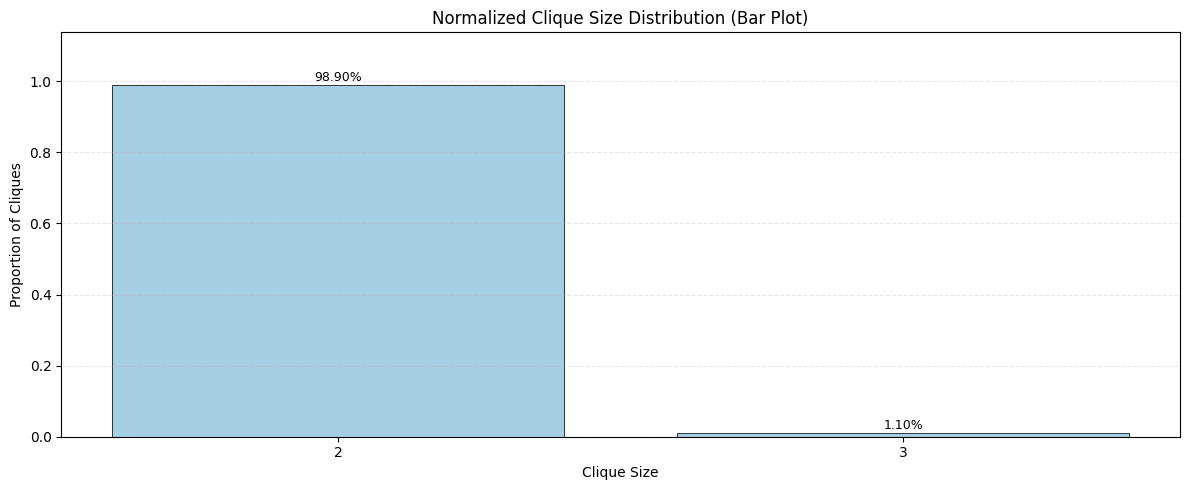

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 367785
  successful rewires  : 6155
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 361630
  avg degree          : 34.0041 -> 37.4045
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Average degree: 37.404474186323036


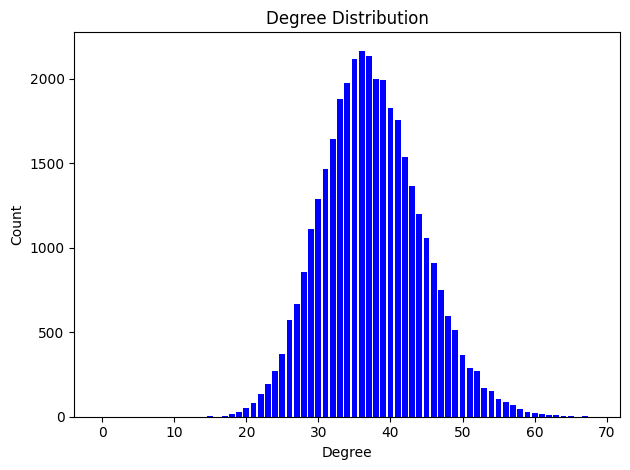

Clique size distribution (raw counts):
  Size 2: 591299 clique(s)
  Size 3: 8778 clique(s)
  Size 4: 2 clique(s)
  Size 5: 6155 clique(s)
Clique sizes present: 2, 3, 4, 5


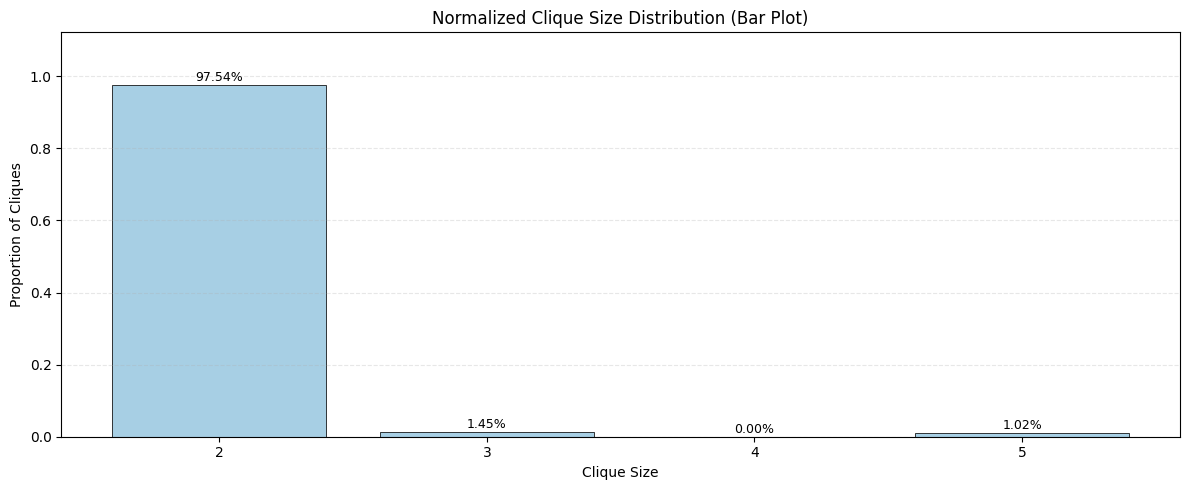

Simulation 3 complete - memory cleared.

Running simulation 4/5
ER network created
Average degree: 39.97571789665603


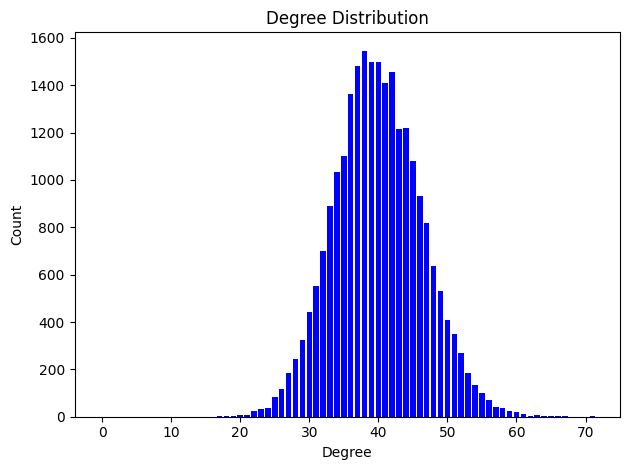

Clique size distribution (raw counts):
  Size 2: 451901 clique(s)
  Size 3: 10490 clique(s)
Clique sizes present: 2, 3


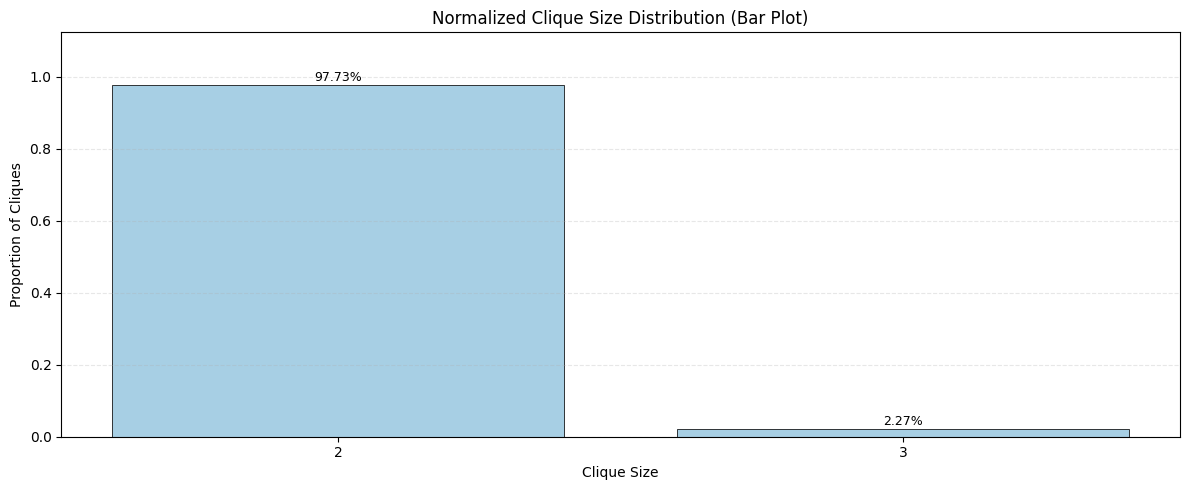

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 246164
  successful rewires  : 4834
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 241330
  avg degree          : 39.9757 -> 43.9732
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Average degree: 43.97323167447064


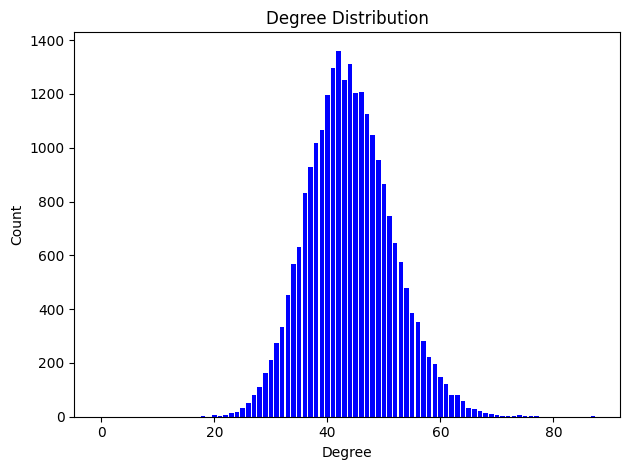

Clique size distribution (raw counts):
  Size 2: 445801 clique(s)
  Size 3: 13875 clique(s)
  Size 4: 9 clique(s)
  Size 5: 4834 clique(s)
Clique sizes present: 2, 3, 4, 5


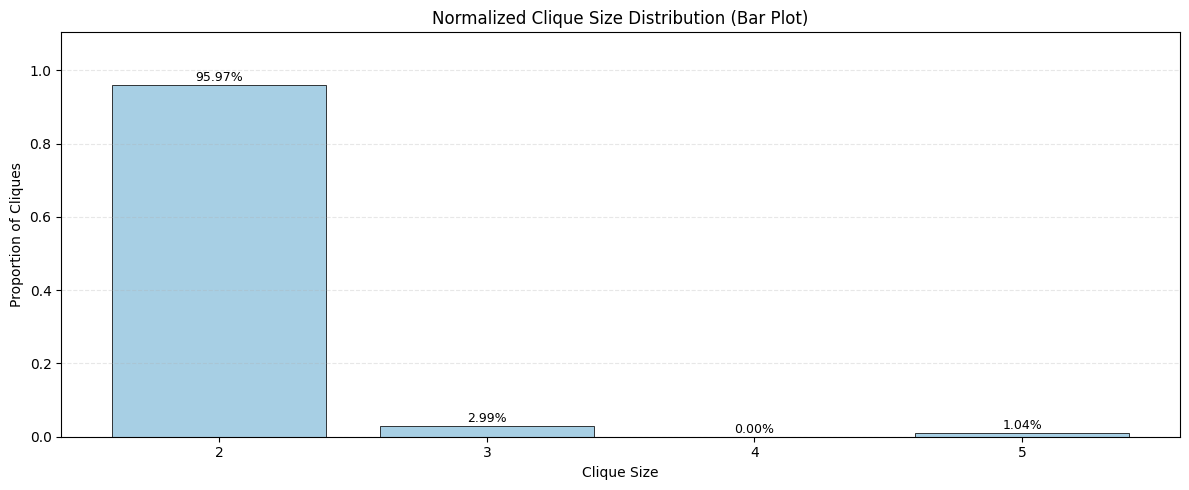

Simulation 4 complete - memory cleared.

Running simulation 5/5
ER network created
Average degree: 47.04132759823297


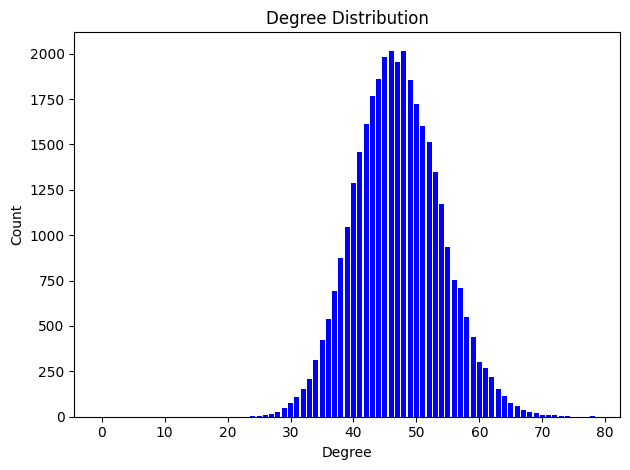

Clique size distribution (raw counts):
  Size 2: 759192 clique(s)
  Size 3: 17229 clique(s)
Clique sizes present: 2, 3


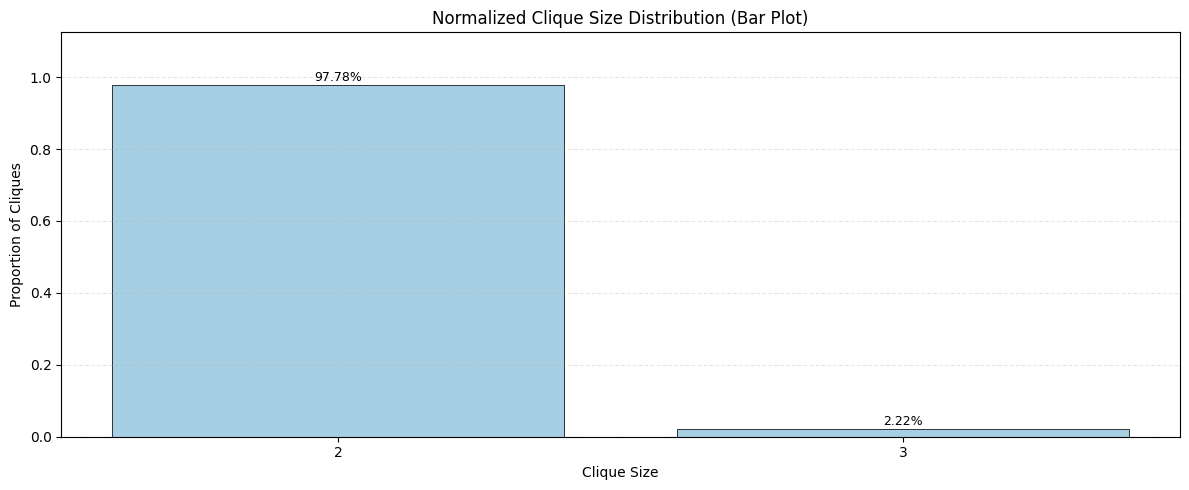

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 352186
  successful rewires  : 8105
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 344081
  avg degree          : 47.0413 -> 51.7454
  stop reason         : max_consecutive_failures
ER network rewired (valid)
Average degree: 51.74540804464078


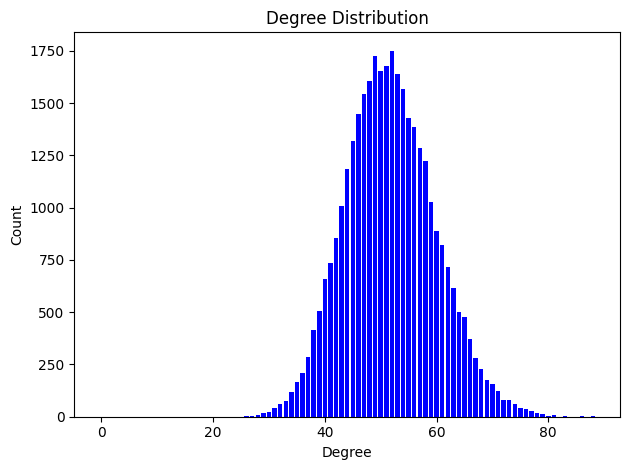

Clique size distribution (raw counts):
  Size 2: 748933 clique(s)
  Size 3: 22934 clique(s)
  Size 4: 10 clique(s)
  Size 5: 8104 clique(s)
Clique sizes present: 2, 3, 4, 5


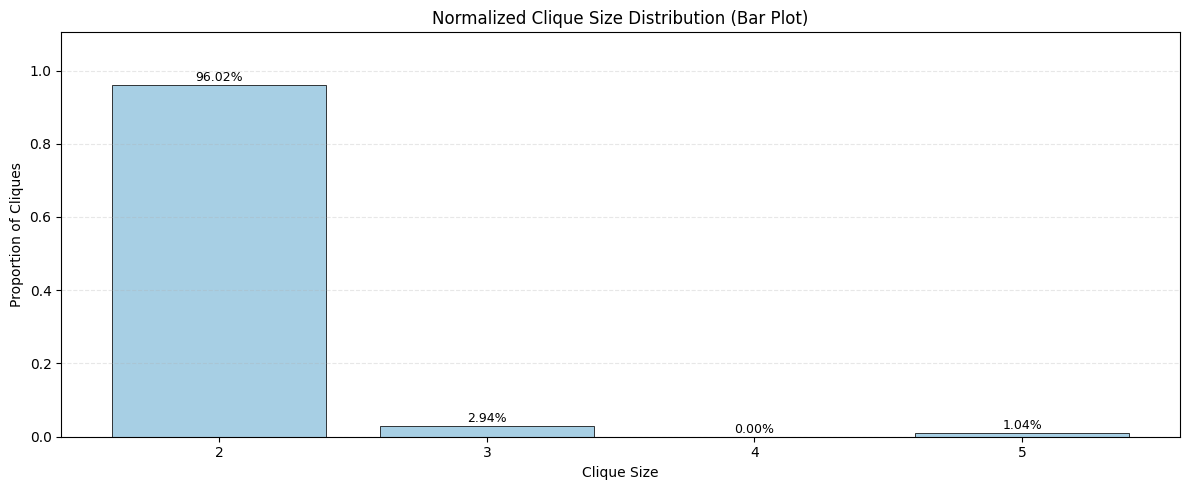

Simulation 5 complete - memory cleared.



In [8]:
run_multiple_simulations(5, 40000, 5, visualise=True)

# Step 5: Future Improvements
While it has been demonstrated that the rewiring process is capable to meet the requirements, going forward there would be some changes and improvements that could be made to optimise the system and to enahance the process of rewiring. These are: 
1. Incorporating parallel processing using multithreading in python. At the moment, the rewiring is a linear process. The code iterates through the nodes and attempts to rewire nodes into cliques, carries out validity of the rewiring, cancels the rewiring if neccisary, and then proceeds to the next node. With parallel processing, multiple nodes (depending on the resource availability) could go through this process at the same time - granted locking of nodes should also be included as to not cause inconsistencies in the network. The primary benefit of this could be to reduce the rewiring time required and allow for larger models of greater sizes to the ones used in this notebook to be processe in a optimal time. 
2. Enhanced Rewiring process. Currently, the process of rewiring covers the foundation with some levels of enhancments with regards to caching, and disallowing existing cliques within the target area to be rewired, and basic rule checking. As with the previous point, the process of node adjustments is sequential which means that rewiring works on a "first come, first serve" basis. By doing this, we could ignore a significant chunch of the network should the degree distribution be exeeded early on in the process - meaning most of the network is never considered. To combat this, it may be beneficial to implmement a random selection process so that the rewiring process is able to consider a wider scope of nodes across the network rather than just those that are first in line. This could allow for more rewiring to be done and more cliques to be formed within the target area.

# Step 6 Conclusions
By running observations at random node sizes within different boundaries, it was still possible to see the observations that were noted on the single simulation (see Output from simulation in step 4) across nearly all of the simulation runs. So it is possible to say that the rewiring process has met the critiera mentioned at the top of this document, though there is still room for improvement and as mentioned, future work may be able to improve the process.  